> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 3 - Tugas 3

> 26 Juni 2024
---
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 6
import seaborn as sns
from itertools import chain

## 1 Basic Plotting / Visualization

---

#### (a)  Write a program with Matplotlib to visualize scatter plot below.

Input

In [2]:
# Values of coordinate x
x = np.arange(0, 5, 0.2)

# Values of coordinate y1 (linear line)
linearFunction = np.vectorize(lambda x : x + 0.25)
y1 = linearFunction(x)

# Values of coordinate y2 (parabolic 1)
parabolicFunction1 = np.vectorize(lambda x : x ** 2)
y2 = parabolicFunction1(x)

# Values of coordinate y3 (parabolic 2)
parabolicFunction2 = np.vectorize(lambda x : 2 * (x ** 2))
y3 = parabolicFunction2(x)

Output

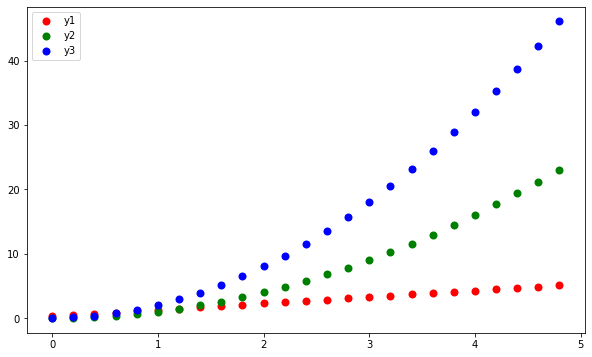

In [3]:
for y, str_y, clr in zip([y1, y2, y3], ['y1', 'y2', 'y3'], ['r', 'g', 'b']):
    plt.scatter(x, y, label = str_y, 
                color = clr, 
                linewidths = 2)
plt.legend()
plt.show()

#### (b) Write a program with matplotlib to visualize line plot below.

Input

In [5]:
# Coordinate (x,y) for line 1 (linewidth : 3)
x1 = [10, 20, 30]
y1 = [40, 15, 20]

# Coordinate (x,y) for line 2 (linewidth : 5)
x2 = [10, 20, 30]
y2 = [20, 40, 15]

Output

,line-1-width-3,line-2-width-5
x,,
10,40,20
20,15,40
30,20,15


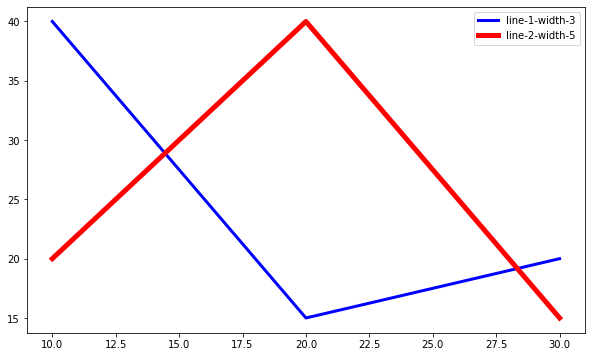

In [6]:
df = pd.DataFrame(np.array([x1, y1, y2]).T, 
                  columns = ['x', 'line-1-width-3', 'line-2-width-5']).set_index('x')
display(df)

plt.plot(df['line-1-width-3'], color = 'b', linewidth = 3)
plt.plot(df['line-2-width-5'], color = 'r', linewidth = 5)
plt.legend(df.columns)
plt.show()

## 2  Visualization of Senior High School’s Dataset in Province West Java

---


This assignment will use dataset from education ministry in Province West Java Indonesia
referring to senior high school data, taken from :

[Jabar Prov Data Pendidikan](https://opendata.jabarprov.go.id/id/dataset?organization=dinas-pendidikan&q=murid&suggestion=on)

From that link, we only choose three datasets to be worked on for data visualization, including amount of schools, students, and teachers for each regencies/districts in West Java province. Here are the things you have to do :

(a) Read all of the CSV files from following three datasets and display the top 5 rows each.
- Number of senior high school unit in West Java : `number_of_senior_high_school_in_west_java_province.csv`

- Number of senior high school’s student in West Java : `number_of_student_in_senior_high_school_in_west_java_province.csv`

- Number of senior high school’s teacher in West Java : `number_of_teacher_in_senior_high_school_in_west_java_province.csv`


In [8]:
# Dataset Read

df_shs = pd.read_csv('data/number_of_senior_high_school_in_west_java_province.csv', index_col = 0)
df_students = pd.read_csv('data/number_of_student_in_senior_high_school_in_west_java_province.csv', index_col = 0)
df_teachers = pd.read_csv('data/number_of_teacher_in_senior_high_school_in_west_java_province.csv', index_col = 0)

In [10]:
# Dataset Display

display(df_shs.head())
display(df_students.head())
display(df_teachers.head())

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_sekolah,satuan,tahun_ajaran
id,,,,,,,
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016
2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,77,UNIT,2015/2016
3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,86,UNIT,2015/2016
4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,107,UNIT,2015/2016
5,32,JAWA BARAT,3205,KABUPATEN GARUT,120,UNIT,2015/2016


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_murid,satuan,tahun_ajaran
id,,,,,,,
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,61153,ORANG,2015/2016
2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,59843,ORANG,2015/2016
3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,36226,ORANG,2015/2016
4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,46428,ORANG,2015/2016
5,32,JAWA BARAT,3205,KABUPATEN GARUT,47270,ORANG,2015/2016


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_guru,satuan,tahun_ajaran
id,,,,,,,
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,2950,ORANG,2015/2016
2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,2353,ORANG,2015/2016
3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,3832,ORANG,2015/2016
4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,2100,ORANG,2015/2016
5,32,JAWA BARAT,3205,KABUPATEN GARUT,2208,ORANG,2015/2016


In [41]:
temp_list = [df_shs, df_students, df_teachers]

print('----Code Similarity Checker----')
code_zipped = zip(df_shs.kode_kabupaten_kota, df_students.kode_kabupaten_kota, df_teachers.kode_kabupaten_kota)
code_similar_check = 0

for i, j, k in code_zipped:
    if (i == j) & (i == k) & (j == k):
        code_similar_check += 1

print(code_similar_check)
print('\n')

print('----Name Similarity Checker----')
name_zipped = zip(df_shs.kode_kabupaten_kota, df_students.kode_kabupaten_kota, df_teachers.kode_kabupaten_kota)
name_similar_check = 0

for i, j, k in name_zipped:
    if (i == j) & (i == k) & (j == k):
        name_similar_check += 1

print(name_similar_check)

----Code Similarity Checker----
162


----Name Similarity Checker----
162


(b) Please do the following operations on the three datasets above :
- Join the three datasets by merge’s pandas operation based on three same columns as
pivot : nama_provinsi, kode_kabupaten_kota, tahun_ajaran. Hint : please use
code snippet below and fill in the blank part.

`merge_result_1_df = pd.merge(……………, ………………, on=[………], suffixes=('',
'remove'), how="inner")`

`final_high_school_df = pd.merge(……………, ………………, on=[………], suffixes=('',
'remove'), how="inner")`

- Display the 5 top rows of final dataframe.
- In process of merging three datasets, the three columns used as pivot before are
duplicated in final dataframe (column name with suffix “_remove”). Remove them
from final dataframe and display again 5 top rows after operation done. Hint : you
can use directly code snippet below or any other suitable method.

`final_high_school_df.drop([i for i in final_high_school_df.columns if
'remove' in i], axis=1, inplace=True)`

- Display the data types of every column in final dataframe.
- Check if there are some missing values in final dataframe. If any of the columns
contains missing value, fill in missing values with zero (for integer) and/or most
frequent values (for categorical/non integer).

In [12]:
# Dataset Merge

merge_result_1_df = pd.merge(df_shs, df_teachers, 
                             on = ['kode_kabupaten_kota'], 
                             suffixes = ('', '_remove'), 
                             how = "inner")
final_high_school_df = pd.merge(merge_result_1_df, df_students, 
                                on = ['kode_kabupaten_kota'], 
                                suffixes = ('', '_remove'), 
                                how = "inner")

# Display New Dataframe 5 Top Rows
display(final_high_school_df.head())
# print(len(final_high_school_df))

# Droping columns with value suffix "remove"
final_high_school_df.drop([i for i in final_high_school_df.columns if 'remove' in i], 
                          axis = 1, 
                          inplace = True)

# Data types diplay in every column
display(final_high_school_df.head())
final_high_school_df.info()
# print(len(final_high_school_df))

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_sekolah,satuan,tahun_ajaran,kode_provinsi_remove,nama_provinsi_remove,nama_kabupaten_kota_remove,jumlah_guru,satuan_remove,tahun_ajaran_remove,kode_provinsi_remove,nama_provinsi_remove,nama_kabupaten_kota_remove,jumlah_murid,satuan_remove,tahun_ajaran_remove
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,2950,ORANG,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,61153,ORANG,2015/2016
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,2950,ORANG,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,66121,ORANG,2016/2017
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,2950,ORANG,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,65388,ORANG,2017/2018
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,2950,ORANG,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,69802,ORANG,2018/2019
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,2950,ORANG,2015/2016,32,JAWA BARAT,KABUPATEN BOGOR,71831,ORANG,2019/2020


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_sekolah,satuan,tahun_ajaran,jumlah_guru,jumlah_murid
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,61153
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,66121
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,65388
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,69802
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,71831


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6804 entries, 0 to 6803
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   kode_provinsi        6804 non-null   int64 
 1   nama_provinsi        6804 non-null   object
 2   kode_kabupaten_kota  6804 non-null   int64 
 3   nama_kabupaten_kota  6804 non-null   object
 4   jumlah_sekolah       6804 non-null   int64 
 5   satuan               6804 non-null   object
 6   tahun_ajaran         6804 non-null   object
 7   jumlah_guru          6804 non-null   int64 
 8   jumlah_murid         6804 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 478.5+ KB


In [13]:
# Missing values check

null_values = final_high_school_df.isna().sum()

if null_values.values.sum() == 0:
    print('There is no missing values on the new dataframe')
elif null_values.values.sum() > 0:
    print(f'There are {null_values.values.sum()} missing values')
    for i in final_high_school_df:
        col_check = final_high_school_df[i]
        if col_check.dtypes == 'object':
            col_check.fillna(col_check.mode())
        elif col_check.dtypes == 'int64':
            col_check.fillna(0)

There is no missing values on the new dataframe


(c) Visualize 10 regency/district with lowest number of teacher in year “2020/2021” with
any diagram/chart you think is appropriate

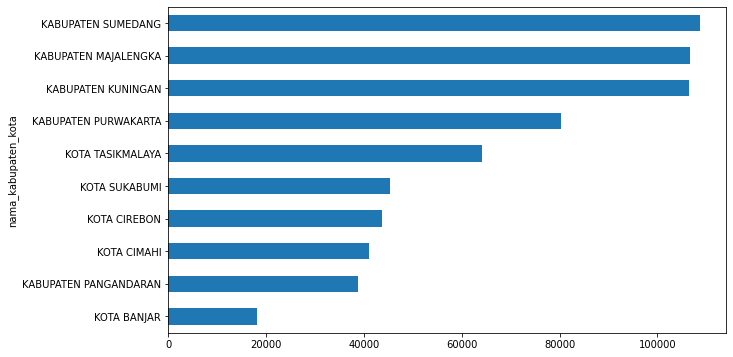

In [17]:
lowest_teacher_sum = pd.pivot_table(data = final_high_school_df[final_high_school_df['tahun_ajaran'] == '2020/2021'],
                     values = 'jumlah_guru',
                     index = 'nama_kabupaten_kota',
                     aggfunc = 'sum').sort_values(by = 'jumlah_guru')

lowest_teacher_sum[:10].plot(kind = 'barh', legend = False)
plt.show()

(d) Visualize 10 regency/district with lowest number of teachers and students ratio in
year “2020/2021” with any diagram/chart you think is appropriate

In [18]:
final_high_school_df['rasio_guru_murid'] = final_high_school_df.jumlah_guru / final_high_school_df.jumlah_murid
final_high_school_df.head()

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_sekolah,satuan,tahun_ajaran,jumlah_guru,jumlah_murid,rasio_guru_murid
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,61153,0.048240
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,66121,0.044615
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,65388,0.045115
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,69802,0.042262
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,71831,0.041069


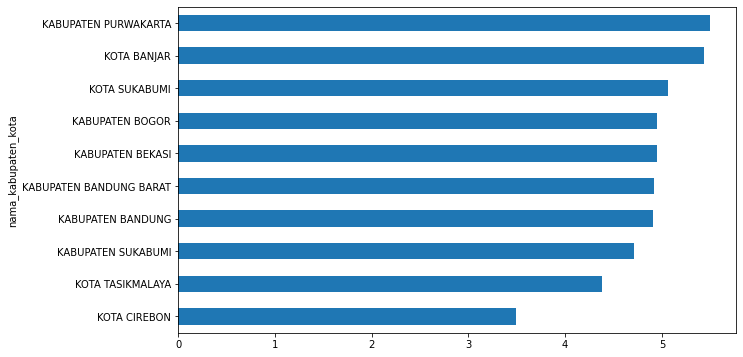

In [19]:
ratio_teacher_student = pd.pivot_table(data = final_high_school_df[final_high_school_df.tahun_ajaran == '2020/2021'],
                                       values = 'rasio_guru_murid',
                                       index = 'nama_kabupaten_kota',
                                       aggfunc = 'sum').sort_values(by = 'rasio_guru_murid')

ratio_teacher_student[:10].plot(kind = 'barh', legend = False)
plt.show()

(e) Visualize 10 regencies/districts with highest percentage of number unit of schools in
year “2020/2021” in pie chart or any diagram/chart you think is appropriate

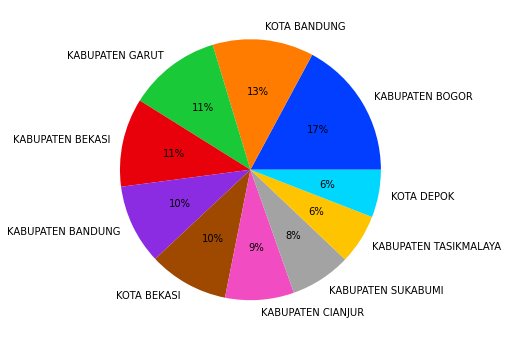

In [20]:
unit_school_percentage = pd.pivot_table(data = final_high_school_df[(final_high_school_df.tahun_ajaran == '2020/2021')],
                                        values = 'jumlah_sekolah',
                                        index = 'nama_kabupaten_kota',
                                        aggfunc = 'sum').sort_values(by = 'jumlah_sekolah',
                                                                     ascending = False)

plt.pie(unit_school_percentage[:10].jumlah_sekolah,
        labels = unit_school_percentage[:10].jumlah_sekolah.index,
        colors = sns.color_palette('bright'),
        autopct = '%.0f%%')
plt.show()

(f) Visualize 10 regency/district with highest number of teachers and schools unit ratio in
year “2020/2021” with any diagram/chart you think is appropriate

In [21]:
final_high_school_df['rasio_guru_sekolah'] = final_high_school_df.jumlah_guru / final_high_school_df.jumlah_sekolah
final_high_school_df.head()

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_sekolah,satuan,tahun_ajaran,jumlah_guru,jumlah_murid,rasio_guru_murid,rasio_guru_sekolah
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,61153,0.048240,17.052023
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,66121,0.044615,17.052023
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,65388,0.045115,17.052023
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,69802,0.042262,17.052023
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,71831,0.041069,17.052023


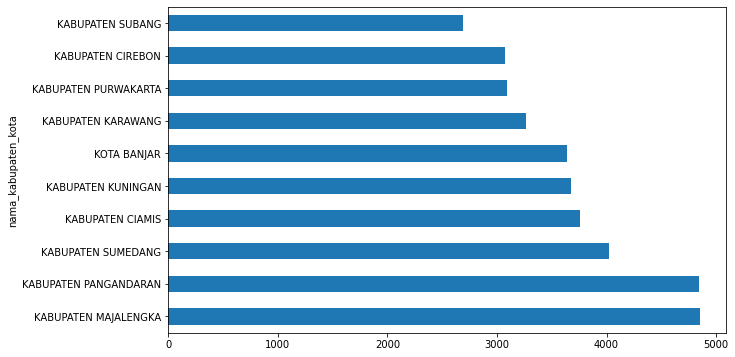

In [22]:
ratio_teacher_school = pd.pivot_table(data = final_high_school_df[(final_high_school_df.tahun_ajaran == '2020/2021')],
                                      values = 'rasio_guru_sekolah',
                                      index = 'nama_kabupaten_kota',
                                      aggfunc = 'sum').sort_values(by = 'rasio_guru_sekolah',
                                                                   ascending = False)

ratio_teacher_school[:10].plot(kind = 'barh', legend = False)
plt.show()

(g) Visualize 10 regency/district with highest number of students and schools unit ratio in
year “2020/2021” with any diagram/chart you think is appropriate

In [23]:
final_high_school_df['rasio_murid_sekolah'] = final_high_school_df.jumlah_murid / final_high_school_df.jumlah_sekolah
final_high_school_df.head()

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,jumlah_sekolah,satuan,tahun_ajaran,jumlah_guru,jumlah_murid,rasio_guru_murid,rasio_guru_sekolah,rasio_murid_sekolah
0,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,61153,0.048240,17.052023,353.485549
1,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,66121,0.044615,17.052023,382.202312
2,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,65388,0.045115,17.052023,377.965318
3,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,69802,0.042262,17.052023,403.479769
4,32,JAWA BARAT,3201,KABUPATEN BOGOR,173,UNIT,2015/2016,2950,71831,0.041069,17.052023,415.208092


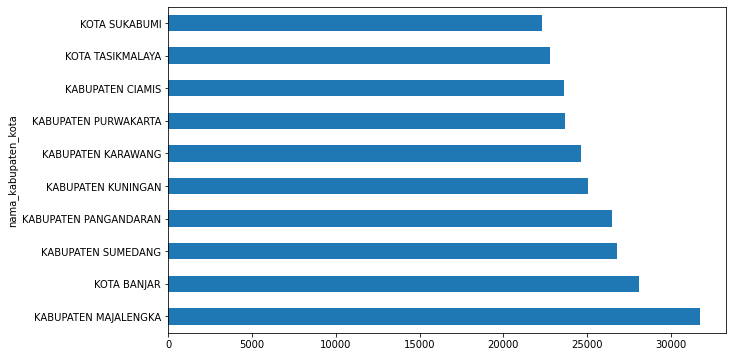

In [24]:
ratio_student_school = pd.pivot_table(data = final_high_school_df[(final_high_school_df.tahun_ajaran == '2020/2021')],
                                      values = 'rasio_murid_sekolah',
                                      index = 'nama_kabupaten_kota',
                                      aggfunc = 'sum').sort_values(by = 'rasio_murid_sekolah',
                                                                   ascending = False)

ratio_student_school[:10].plot(kind = 'barh', legend = False)
plt.show()

## 3  Plotting with Seaborn

---

You are strictly only allowed to use seaborn library for the visualization on this number (you are
allowed subplots using plt / matplotlib.pyplot, but the chart have to use seaborn)

a. Read the Pokemon.csv data and put it to a dataframe

In [25]:
df_pokemon = pd.read_csv('data/Pokemon.csv', index_col = 0)
df_pokemon

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...
719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True


b. Preprocess the data if you think it’s necessary. If not, explain your answer

> *Special note for Pokemon Types: each pokemon can either have 1, or 2 types, you
can choose whatever technique you want to preprocess this

In [26]:
df_pokemon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 1 to 721
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        800 non-null    object
 1   Type 1      800 non-null    object
 2   Type 2      414 non-null    object
 3   Total       800 non-null    int64 
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 75.8+ KB


In [27]:
df_pokemon['Type 2'].fillna('-', inplace = True)

c. Create a pie chart representing the number of legendaries vs non-legendary pokemons.

In [28]:
df_pokemon.Legendary.value_counts()

Legendary
False    735
True      65
Name: count, dtype: int64

,count
Legendary,
False,735
True,65


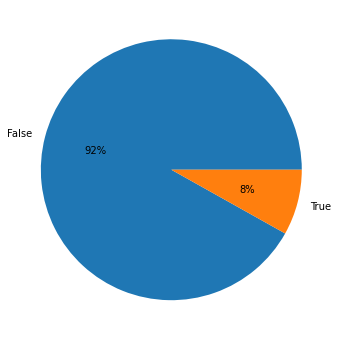

In [29]:
rarity_count = pd.DataFrame(df_pokemon.Legendary.value_counts())
display(rarity_count)

plt.pie(rarity_count['count'],
        labels = rarity_count.index,
        autopct = '%.0f%%')
plt.show()

d. Visualize the number of pokemon and their types (type 1 & type 2) in a bar plot

- 1 bar plot for type 1
- 1 bar plot for type 2

In [30]:
type_1_count = df_pokemon.groupby('Type 1').Name.agg('count').sort_values()
type_2_count = df_pokemon.groupby('Type 2').Name.agg('count').sort_values()

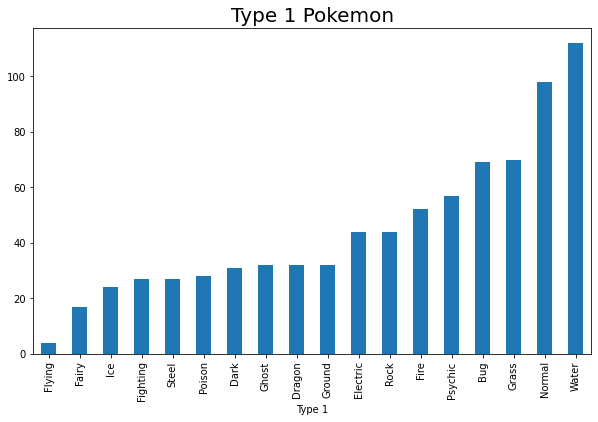

In [34]:
type_1_count.plot(kind = 'bar')
plt.title('Type 1 Pokemon', fontsize = 20)
plt.show()

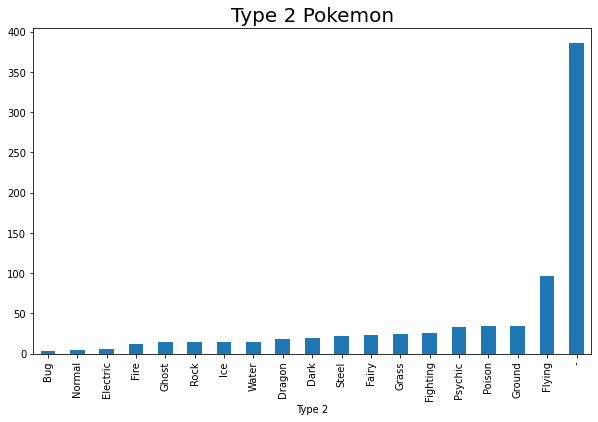

In [35]:
type_2_count.plot(kind = 'bar')
plt.title('Type 2 Pokemon', fontsize = 20)
plt.show()

e. Create a line chart which plots the average stat (HP, Attack, Defense, Special Attack, Special
Defense, and Speed) of pokemons across it’s generations.

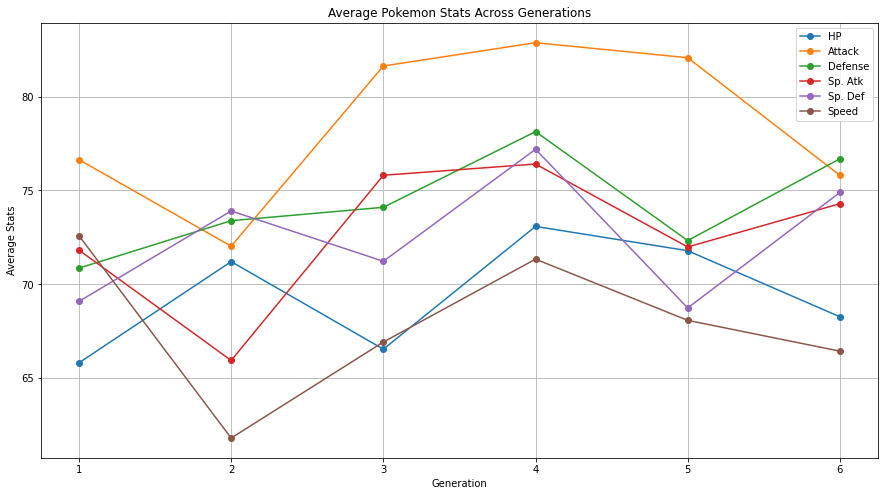

In [36]:
colnames = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

average_stats = df_pokemon.groupby('Generation')[colnames].agg('mean')

plt.figure(figsize = (15, 8))
for column in average_stats.columns:
    plt.plot(average_stats.index, average_stats[column], marker='o', label=column)

plt.xlabel('Generation')
plt.ylabel('Average Stats')
plt.title('Average Pokemon Stats Across Generations')
plt.legend()
plt.grid(True)
plt.show()

## 4  Hotel Booking

---

There is Jakarta hotel booking data (hotel_booking.csv provided). Use data only arrival_date_year in
2016. Then do the following processing.

a. Read the CSV file and get the average number of bookings each month and visualize it in
Barchart

In [37]:
df_hotel = pd.read_csv('data/hotel_bookings.csv')
display(df_hotel.head())
df_hotel.info()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,hotel
arrival_date_month,
January,2248
February,3891
March,4824
April,5428
May,5478
June,5292
July,4572
August,5063
September,5394


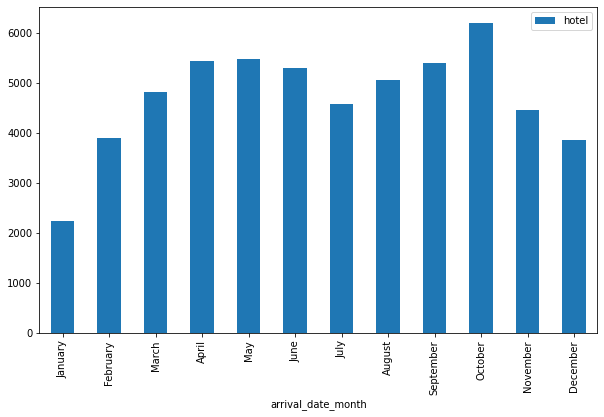

In [41]:
# get the average number of bookings each month and visualize it in Barchart
df_hotel_2016 = df_hotel[df_hotel.arrival_date_year == 2016].reset_index(drop = True)

avg_book_permonth = pd.pivot_table(data = df_hotel_2016,
                                   values = 'hotel',
                                   index = 'arrival_date_month',
                                   aggfunc = 'count')

month_order = ['January', 'February', 'March', 'April', 
               'May', 'June', 'July', 'August', 
               'September', 'October', 'November', 'December']


avg_book_permonth.index = pd.CategoricalIndex(avg_book_permonth.index, 
                                              categories = month_order)
avg_book_permonth.sort_index(inplace = True)
display(avg_book_permonth)

avg_book_permonth.plot(kind = 'bar')
plt.show()

b. Visualize the number of adult guests into diagram / chart that you think is appropriate

,adults
hotel,
City Hotel,70568
Resort Hotel,34396


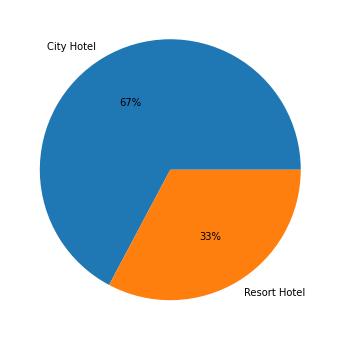

In [42]:
count_adult_guests = pd.pivot_table(data = df_hotel_2016,
                                    values = 'adults',
                                    index = 'hotel',
                                    aggfunc = 'sum')
display(count_adult_guests)

plt.pie(count_adult_guests.adults,
        labels = count_adult_guests.index,
        autopct = '%.0f%%')
plt.show()

c. Visualize the number of canceled bookings (is_cancelled, 0 = not cancelled, 1 = canceled)
each week using the appropriate chart

,cancel_bookings
arrival_date_week_number,
24,464
16,455
43,655
35,394
52,232


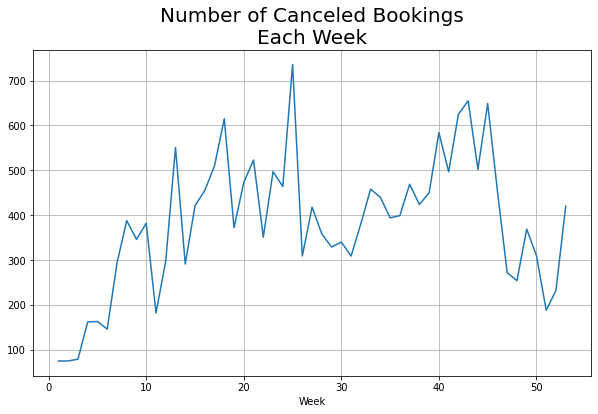

In [44]:
canceled_books_weekly = pd.pivot_table(data = df_hotel_2016[df_hotel_2016.is_canceled == 1],
                                       values = ['is_canceled'],
                                       columns = ['arrival_date_week_number'],
                                       aggfunc = 'count').T.rename({'is_canceled':'cancel_bookings'},
                                                                   axis = 1)
display(canceled_books_weekly.sample(5))
plt.plot(canceled_books_weekly)
plt.title('Number of Canceled Bookings\nEach Week', 
          fontsize = 20)
plt.xlabel('Week')
plt.grid()
plt.show()